In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Models
from xgboost import XGBClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

NOTEBOOK_DIR = Path('.').resolve()
FELIPE_DIR   = NOTEBOOK_DIR.parent / "Felipe's model"
BLATT_FILE   = FELIPE_DIR / 'blattmann_processed.xlsx'
IOT_FILE     = FELIPE_DIR / 'iot_labeled.xlsx'

FEATURES     = ['temperature', 'humidity', 'tvoc_ppb', 'eco2_ppm']
CLASS_NAMES  = ['Normal', 'Cooking', 'Fire']
RANDOM_STATE = 42

In [2]:
# Load Blattmann data and remap labels for 3-class scheme
if not BLATT_FILE.exists():
    print(f"Missing: {BLATT_FILE}")
else:
    blatt = pd.read_excel(BLATT_FILE, sheet_name='Blattmann Processed')
    if 'label' in blatt.columns:
        blatt = blatt.rename(columns={'label': 'blatt_label'})
    
    blatt['class_id'] = blatt['blatt_label'].map({'No Smoke': 0, 'Smoke': 2})
    blatt['label']    = blatt['class_id'].map({0: 'Normal', 2: 'Fire'})
    blatt = blatt.dropna(subset=['class_id'] + FEATURES)
    blatt['class_id'] = blatt['class_id'].astype(int)

    print(f"Blattmann samples: {len(blatt):,}")
    print(blatt['label'].value_counts().to_string())

Blattmann samples: 62,630
label
Fire      44757
Normal    17873


In [3]:
# Load IoT data
if not IOT_FILE.exists():
    print(f"Missing: {IOT_FILE}")
else:
    iot = pd.read_excel(IOT_FILE)
    print(f"IoT samples: {len(iot):,}")
    print(iot['label'].value_counts().to_string())

IoT samples: 549
label
Cooking    329
Normal     220


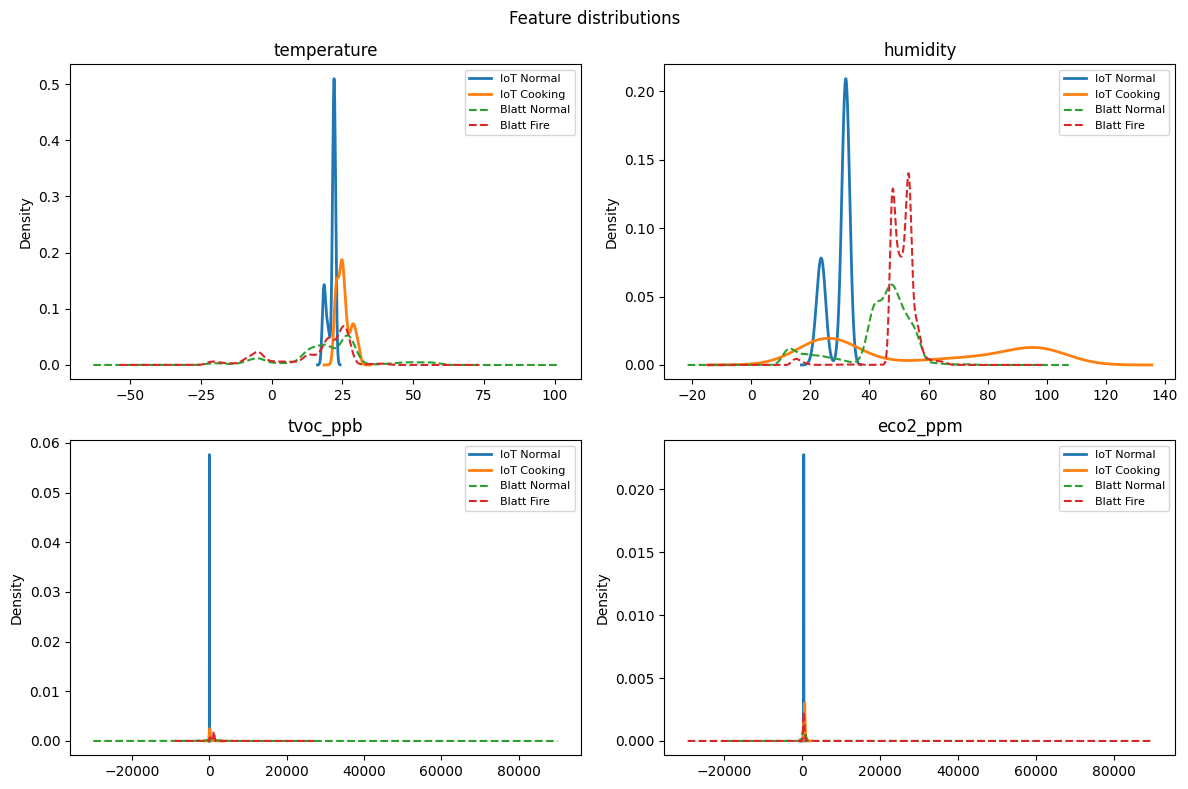

In [4]:
# feature distributions per class and dataset
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Feature distributions')

for ax, feat in zip(axes.flat, FEATURES):
    for cid, name in [(0, 'Normal'), (1, 'Cooking')]:
        iot[iot['class_id'] == cid][feat].plot.kde(ax=ax, label=f'IoT {name}', lw=2)
    for cid, name in [(0, 'Normal'), (2, 'Fire')]:
        blatt[blatt['class_id'] == cid][feat].plot.kde(ax=ax, label=f'Blatt {name}', lw=1.5, ls='--')
    ax.set_title(feat); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [5]:
# split each dataset separately so IoT test set isn't dominated by Blattmann's size
X_b_tr, X_b_te, y_b_tr, y_b_te = train_test_split(
    blatt[FEATURES].values, blatt['class_id'].values,
    test_size=0.2, random_state=RANDOM_STATE, stratify=blatt['class_id'].values)

X_i_tr, X_i_te, y_i_tr, y_i_te = train_test_split(
    iot[FEATURES].values, iot['class_id'].values,
    test_size=0.2, random_state=RANDOM_STATE, stratify=iot['class_id'].values)

# combine for training
X_train = np.vstack([X_b_tr, X_i_tr])
y_train  = np.concatenate([y_b_tr, y_i_tr])

print(f"Train: {len(y_train):,}  |  Blattmann test: {len(y_b_te):,}  |  IoT test: {len(y_i_te):,}")
for cid, name in enumerate(CLASS_NAMES):
    n = (y_train == cid).sum()
    if n: print(f"  {name}: {n:,}")

Train: 50,543  |  Blattmann test: 12,526  |  IoT test: 110
  Normal: 14,474
  Cooking: 263
  Fire: 35,806


In [6]:
# fit scaler on train only — applying to test avoids data leakage
scaler = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_b_test_sc = scaler.transform(X_b_te)
X_i_test_sc = scaler.transform(X_i_te)

joblib.dump(scaler, NOTEBOOK_DIR / 'scaler.joblib')

["C:\\Users\\guiga\\S26\\SEP4\\System\\MlServer\\Guillermo's model\\scaler.joblib"]

In [7]:
# Advanced model: HistGradientBoostingClassifier or XGBClassifier
# Since classes are highly imbalanced, we can compute class weights or just use HistGradientBoosting with class weighting natively if available.
# We'll use XGBoost as it's widely available and performs exceptionally well on tabular datasets.

try:
    from xgboost import XGBClassifier
    # Calculate class weights
    from sklearn.utils.class_weight import compute_class_weight
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    weight_dict = dict(zip(classes, weights))
    
    # We assign weights to standard sample_weight 
    sample_weights = np.array([weight_dict[y] for y in y_train])
    
    model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        use_label_encoder=False,
        eval_metric='mlogloss'
    )
    # Fit the xgboost model
    model.fit(X_train_sc, y_train, sample_weight=sample_weights)
    print("Trained XGBClassifier model.")

except ImportError:
    print("XGBoost not installed. Using HistGradientBoostingClassifier instead...")
    
    # HistGradientBoosting doesn't formally take 'class_weight' in all versions
    # so we manually pass sample_weight during fit.
    from sklearn.utils.class_weight import compute_sample_weight
    sample_weights = compute_sample_weight('balanced', y_train)

    model = HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_depth=8,
        min_samples_leaf=10,
        random_state=RANDOM_STATE,
        l2_regularization=0.1
    )
    model.fit(X_train_sc, y_train, sample_weight=sample_weights)
    print("Trained HistGradientBoostingClassifier model.")

joblib.dump(model, NOTEBOOK_DIR / 'model_classifier.joblib')

Trained XGBClassifier model.


["C:\\Users\\guiga\\S26\\SEP4\\System\\MlServer\\Guillermo's model\\model_classifier.joblib"]

CV F1-macro: 0.9944 +/- 0.0049


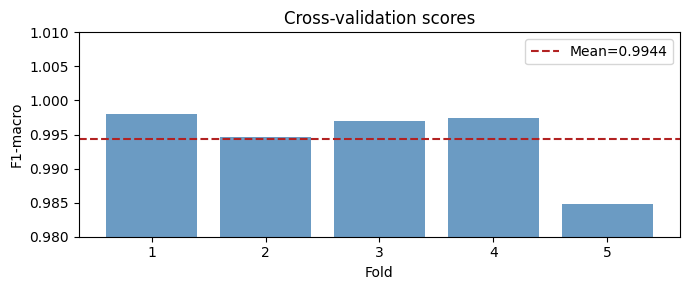

In [8]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# To use cross_val_score with sample_weights on standard sklearn models:
fit_params = {}
if 'sample_weights' in locals() and hasattr(model, 'fit'):
    fit_params['sample_weight'] = sample_weights

cv_scores = cross_val_score(
    model, X_train_sc, y_train, 
    cv=skf, scoring='f1_macro', 
    params={'sample_weight': sample_weights} if hasattr(model, 'estimators_') else fit_params
)

print(f"CV F1-macro: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

plt.figure(figsize=(7, 3))
plt.bar(range(1, 6), cv_scores, color='steelblue', alpha=0.8)
plt.axhline(cv_scores.mean(), color='firebrick', ls='--', label=f'Mean={cv_scores.mean():.4f}')
plt.ylim(0.98, 1.01)
plt.xlabel('Fold'); plt.ylabel('F1-macro')
plt.title('Cross-validation scores'); plt.legend()
plt.tight_layout()
plt.show()

In [9]:
y_b_pred = model.predict(X_b_test_sc)
y_i_pred = model.predict(X_i_test_sc)

print("Blattmann test set")
print(classification_report(y_b_te, y_b_pred, target_names=CLASS_NAMES, labels=[0,1,2], zero_division=0))

Blattmann test set
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      3575
     Cooking       0.00      0.00      0.00         0
        Fire       1.00      1.00      1.00      8951

    accuracy                           1.00     12526
   macro avg       0.66      0.66      0.66     12526
weighted avg       1.00      1.00      1.00     12526



In [10]:
print("IoT device test set")
print(classification_report(y_i_te, y_i_pred, target_names=CLASS_NAMES, labels=[0,1,2], zero_division=0))

IoT device test set
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99        44
     Cooking       1.00      0.98      0.99        66
        Fire       0.00      0.00      0.00         0

    accuracy                           0.99       110
   macro avg       0.66      0.66      0.66       110
weighted avg       0.99      0.99      0.99       110



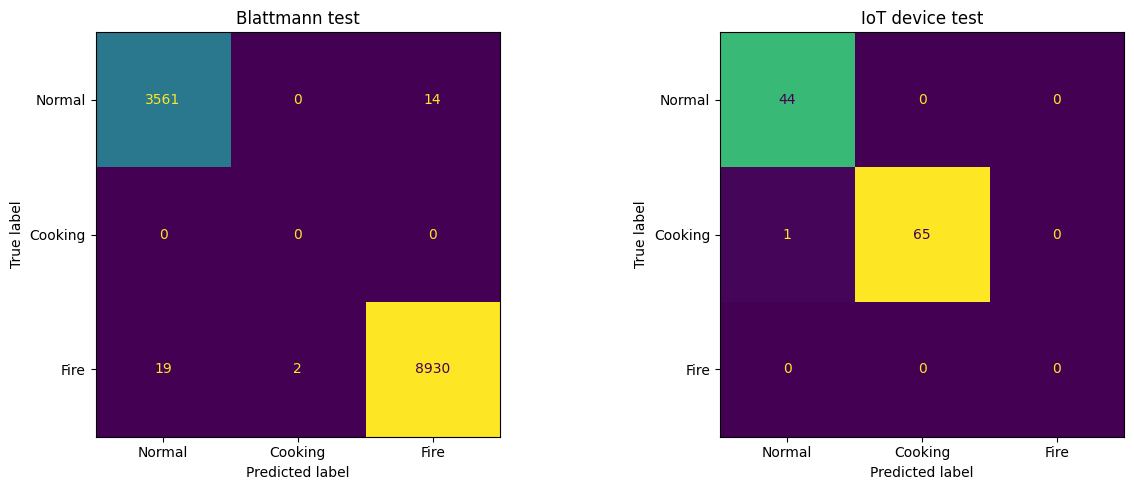

Cooking->Fire errors (IoT): 0


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_b_te, y_b_pred, 'Blattmann test'),
    (axes[1], y_i_te, y_i_pred, 'IoT device test'),
]:
    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()

print(f"Cooking->Fire errors (IoT): {confusion_matrix(y_i_te, y_i_pred, labels=[0,1,2])[1][2]}")

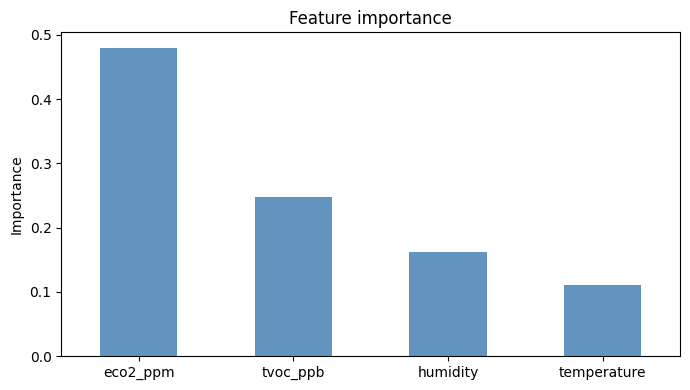

eco2_ppm       0.4801
tvoc_ppb       0.2479
humidity       0.1619
temperature    0.1100


In [12]:
if hasattr(model, 'feature_importances_'):
    fi = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)

    plt.figure(figsize=(7, 4))
    fi.plot.bar(color='steelblue', alpha=0.85)
    plt.title('Feature importance'); plt.ylabel('Importance')
    plt.xticks(rotation=0); plt.tight_layout()
    plt.show()

    print(fi.round(4).to_string())
else:
    print("Model does not provide feature_importances_ (e.g. HistGradientBoostingClassifier without specific property).")

In [13]:
train_f1 = f1_score(y_train, model.predict(X_train_sc), average='macro')
cv_f1    = cv_scores.mean()
gap      = train_f1 - cv_f1

print(f"Train F1: {train_f1:.4f}  |  CV F1: {cv_f1:.4f}  |  Gap: {gap:.4f}")
print("no overfitting" if gap < 0.02 else "mild overfitting" if gap < 0.05 else "overfitting detected")

Train F1: 0.9995  |  CV F1: 0.9944  |  Gap: 0.0052
no overfitting
